## Assignment2: Group 135: Restaurant Review Sentiment Analysis
#### Group Details

| Name | BITS ID | Contribution |
|------|---------|-------------|
| VIJENDRA SINGH RAJPUT | 2024AC05947 | 100% |
| GAUTAM AGARWAL | 2024AC05561 | 100% |
| HARLALKA HARSH AJAY NISHA | 2024AC05842 | 100% |
| NEERADI CHANDRA SAGAR | 2024AC05001 | 100% |
| SUMATHI D | 2024AD05499 | 100% |

---

### Ggiven dataset for assignment: "output.csv"
Data set Link: link: https://drive.google.com/file/d/1d8eyQEtxje_uPhV9ZROk-BWAyziU3N84/view?usp=sharing
- Contains 1,000 reviews text
- Columns: Review, Liked

---

**Objective:** Build a prediction model to predict whether a review on the restaurant is positive or negative.

**Dataset:** Restaurant Review dataset with columns 'Liked' (0 or 1) and 'Review'

## Installing Required Libraries

In [1]:
# Install required packages if not already installed
%pip install pandas numpy matplotlib seaborn nltk scikit-learn wordcloud gensim

Note: you may need to restart the kernel to use updated packages.


## Importing Required Libraries

In [2]:
# import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK imports
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

# Download required NLTK data packages
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

# WordCloud
from wordcloud import WordCloud

# Gensim for Word2Vec (Skip-gram and CBOW)
from gensim.models import Word2Vec

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vijendra/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/vijendra/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vijendra/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/vijendra/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/vijendra/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/vijendra/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nl

All libraries imported successfully!


## Q1: Load Dataset and Create Dataframe (1 Mark)

Download the dataset and create a dataframe named as **Rest_rev** then check the head, info, and describe methods on created dataframe.

In [3]:
# Load the dataset
# Note: We download the given dataset from the provided Google Drive link - filename is 'output.csv'
# given link: https://drive.google.com/file/d/1d8eyQEtxje_uPhV9ZROk-BWAyziU3N84/view?usp=sharing

try:
    # Create a dataframe named as Rest_rev
    Rest_rev = pd.read_csv('output.csv')
except:
    print("Please download the dataset and place it in the working directory")
    print("Dataset link: https://drive.google.com/file/d/1d8eyQEtxje_uPhV9ZROk-BWAyziU3N84/view?usp=sharing")
    
print(f"Dataset loaded successfully with shape: {Rest_rev.shape}")

# Display the first few rows
print("Head of the dataset:")
print(Rest_rev.head())

# Display information about the dataset
print("\nInfo of the dataset:")
print(Rest_rev.info())

# Display statistical description of the dataset
print("\nDescription of the dataset:")
print(Rest_rev.describe())

Dataset loaded successfully with shape: (1000, 2)
Head of the dataset:
                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1

Info of the dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0    Review  1000 non-null   str  
 1   Liked    1000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 15.8 KB
None

Description of the dataset:
            Liked
count  1000.00000
mean      0.50000
std       0.50025
min       0.00000
25%       0.00000
50%       0.50000
75%       1.00000
max       1.00000


## Q2: Pre-processing Steps (1 Mark)

Perform pre-processing steps like Removing Punctuations, Numbers, and Special Characters, Stop Words in dataset.

In [4]:
# Pre-process the text by:
# 1. Converting to lowercase
# 2. Removing special characters, numbers, and punctuation
# 3. Removing extra whitespaces
# 4. Removing stop words

def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters, numbers, and punctuation (keep only alphabets)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize
    words = text.split()
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    
    # Join words back to string
    processed_text = ' '.join(words)
    
    return processed_text

# Apply preprocessing
if ' Review' in Rest_rev.columns:
    # in data the Review column has a leading space
    Rest_rev['preprocessed_Review'] = Rest_rev[' Review'].apply(preprocess_text)
    
    print("Pre-processing completed!")
    print("\nPrint some sample of original vs preprocessed reviews:")
    print(Rest_rev[[' Review', 'preprocessed_Review']].head())
else:
    print("Error: ' Review' column not found in Rest_rev dataframe.")
    print("Please make sure to run Cell 6 (Load Dataset) first to load the data.")
    print(f"Available columns: {list(Rest_rev.columns)}")

Pre-processing completed!

Print some sample of original vs preprocessed reviews:
                                              Review  \
0                           Wow... Loved this place.   
1                                 Crust is not good.   
2          Not tasty and the texture was just nasty.   
3  Stopped by during the late May bank holiday of...   
4  The selection on the menu was great and so wer...   

                                 preprocessed_Review  
0                                    wow loved place  
1                                         crust good  
2                                tasty texture nasty  
3  stopped late may bank holiday rick steve recom...  
4                        selection menu great prices  


## Q3: Normalize Review (1 Mark)

Normalize review by using Stemming or Lemmatization.

In [5]:
# Using Lemmatization for normalization

lemmatizer = WordNetLemmatizer()

# Lemmatize the text
def lemmatize_text(text):

    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)

# Using Lemmatization (generally preferred for better word forms)
Rest_rev['normalized_Review'] = Rest_rev['preprocessed_Review'].apply(lemmatize_text)

print("Normalization using Lemmatization completed!")
print("\nComparison:")
print(Rest_rev[[' Review', 'preprocessed_Review', 'normalized_Review']].head())



Normalization using Lemmatization completed!

Comparison:
                                              Review  \
0                           Wow... Loved this place.   
1                                 Crust is not good.   
2          Not tasty and the texture was just nasty.   
3  Stopped by during the late May bank holiday of...   
4  The selection on the menu was great and so wer...   

                                 preprocessed_Review  \
0                                    wow loved place   
1                                         crust good   
2                                tasty texture nasty   
3  stopped late may bank holiday rick steve recom...   
4                        selection menu great prices   

                                   normalized_Review  
0                                    wow loved place  
1                                         crust good  
2                                tasty texture nasty  
3  stopped late may bank holiday rick steve reco

## Q4: Create cleaned_Review Column and Word Cloud (1 Mark)

Preprocessed Review should be included in the Rest_rev data frame as **cleaned_Review**. Plot word cloud for all classes of the Review.

In [6]:
# Create cleaned_Review column
Rest_rev['cleaned_Review'] = Rest_rev['normalized_Review']

print("cleaned_Review column added to Rest_rev dataframe!")
print("\nFinal dataframe structure:")
print(Rest_rev[[' Review', 'cleaned_Review', 'Liked']].head(10))

cleaned_Review column added to Rest_rev dataframe!

Final dataframe structure:
                                              Review  \
0                           Wow... Loved this place.   
1                                 Crust is not good.   
2          Not tasty and the texture was just nasty.   
3  Stopped by during the late May bank holiday of...   
4  The selection on the menu was great and so wer...   
5     Now I am getting angry and I want my damn pho.   
6              Honeslty it didn't taste THAT fresh.)   
7  The potatoes were like rubber and you could te...   
8                          The fries were great too.   
9                                     A great touch.   

                                      cleaned_Review  Liked  
0                                    wow loved place      1  
1                                         crust good      0  
2                                tasty texture nasty      0  
3  stopped late may bank holiday rick steve recom...    

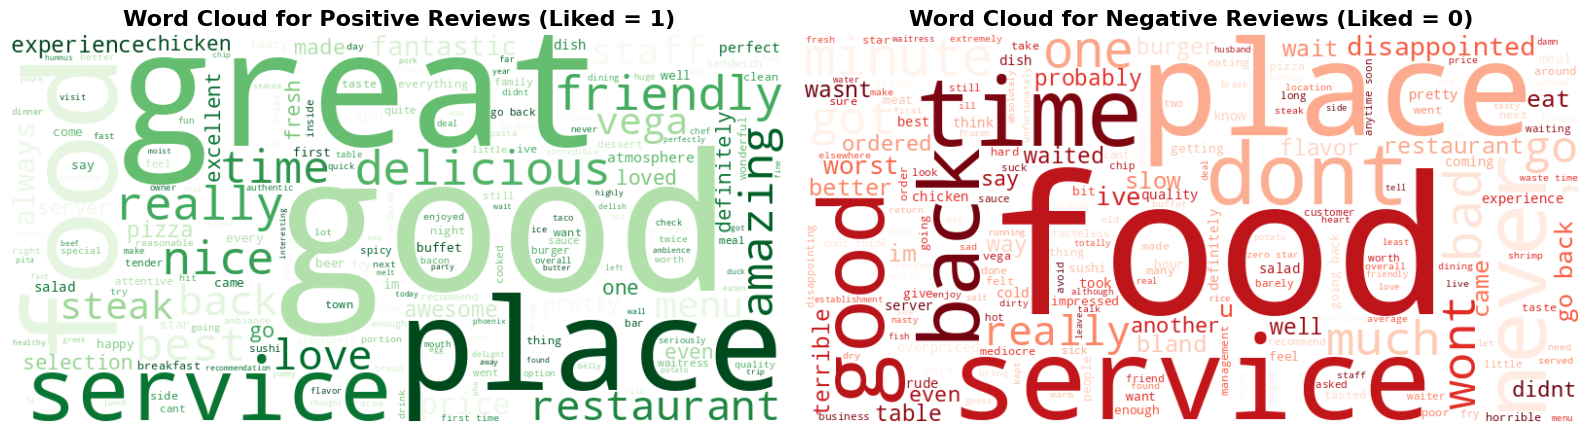

Word clouds generated for both classes!


In [7]:
# Plot word cloud for all classes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Word cloud for Positive reviews (Liked = 1)
positive_reviews = ' '.join(Rest_rev[Rest_rev['Liked'] == 1]['cleaned_Review'])
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', 
                               colormap='Greens').generate(positive_reviews)

axes[0].imshow(wordcloud_positive, interpolation='bilinear')
axes[0].set_title('Word Cloud for Positive Reviews (Liked = 1)', fontsize=16, fontweight='bold')
axes[0].axis('off')

# Word cloud for Negative reviews (Liked = 0)
negative_reviews = ' '.join(Rest_rev[Rest_rev['Liked'] == 0]['cleaned_Review'])
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', 
                               colormap='Reds').generate(negative_reviews)

axes[1].imshow(wordcloud_negative, interpolation='bilinear')
axes[1].set_title('Word Cloud for Negative Reviews (Liked = 0)', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Word clouds generated for both classes!")

## Q5: Create X and y, Train Models with Skip-gram and CBOW (4 Marks)

Create two objects X and y. X will be the 'cleaned_Review' column of Rest_rev data frame and y will be the 'liked' column.

In [8]:
# Create two object X and y
X = Rest_rev['cleaned_Review']
y = Rest_rev['Liked']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

X shape: (1000,)
y shape: (1000,)

Class distribution:
Liked
1    500
0    500
Name: count, dtype: int64


In [9]:
# Tokenize the cleaned reviews for Word2Vec
tokenized_reviews = [review.split() for review in X]

print(f"Number of tokenized reviews: {len(tokenized_reviews)}")
print(f"\nExample tokenized review: {tokenized_reviews[0]}")
print(f"\nExample tokenized review: {tokenized_reviews[100]}")

Number of tokenized reviews: 1000

Example tokenized review: ['wow', 'loved', 'place']

Example tokenized review: ['server', 'fantastic', 'found', 'wife', 'love', 'roasted', 'garlic', 'bone', 'marrow', 'added', 'extra', 'meal', 'another', 'marrow', 'go']


### 5a. Skip-gram Model with Decision Tree

In [10]:
# Create Skip-gram model (sg=1 for Skip-gram)
skipgram_model = Word2Vec(sentences=tokenized_reviews, 
                          vector_size=100,  # Dimensionality of word vectors
                          window=5,          # Context window size
                          min_count=1,       # Minimum word frequency
                          sg=1,              # 1 for Skip-gram, 0 for CBOW
                          workers=4,
                          seed=41)

print("Skip-gram model trained successfully!")
print(f"Vocabulary size: {len(skipgram_model.wv)}")

Skip-gram model trained successfully!
Vocabulary size: 1812


In [11]:
# Get document vector by averaging word vectors
def get_document_vector(tokens, model):

    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# Convert reviews to vectors using Skip-gram
X_skipgram = np.array([get_document_vector(tokens, skipgram_model) for tokens in tokenized_reviews])

print(f"Skip-gram feature matrix shape: {X_skipgram.shape}")
print(f"Document vectors created using Skip-gram model : {X_skipgram}")

Skip-gram feature matrix shape: (1000, 100)
Document vectors created using Skip-gram model : [[ 0.00470501  0.01006576 -0.00655434 ... -0.00621526 -0.00126469
   0.00360873]
 [ 0.00881559  0.01291395 -0.00381454 ... -0.00791176 -0.00194563
   0.0018082 ]
 [ 0.00186446  0.00425861 -0.00179409 ... -0.00648083  0.00227718
   0.00333772]
 ...
 [ 0.00768884  0.00262606 -0.00286318 ... -0.00619368 -0.00128249
  -0.00248257]
 [ 0.01167687  0.00532678 -0.00478229 ... -0.00347923  0.00145783
  -0.00089236]
 [ 0.00713368  0.00544335 -0.00235187 ... -0.00111291  0.00348309
  -0.0009301 ]]


In [12]:
# Split data into training and testing sets for Skip-gram
X_train_sg, X_test_sg, y_train_sg, y_test_sg = train_test_split(
    X_skipgram, y, test_size=0.2, random_state=41, stratify=y
)

print(f"Skip-gram Training set size: {X_train_sg.shape[0]}")
print(f"Skip-gram Testing set size: {X_test_sg.shape[0]}")

Skip-gram Training set size: 800
Skip-gram Testing set size: 200


In [13]:
# Train Decision Tree model with Skip-gram features
dt_skipgram = DecisionTreeClassifier(random_state=41, max_depth=10)
dt_skipgram.fit(X_train_sg, y_train_sg)

# Make predictions
y_train_pred_sg = dt_skipgram.predict(X_train_sg)
y_test_pred_sg = dt_skipgram.predict(X_test_sg)

print(f"Decision Tree trained with Skip-gram features!")
print(f"Training prediction --> {y_train_pred_sg}")
print(f"Testing prediction --> {y_test_pred_sg}")

Decision Tree trained with Skip-gram features!
Training prediction --> [0 0 1 0 1 1 0 0 1 1 1 1 0 0 1 0 0 1 0 0 0 0 1 0 0 1 1 0 1 1 1 1 0 0 0 1 1
 1 0 1 1 1 1 1 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 0
 1 1 1 1 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0
 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0
 0 0 0 0 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 1 0 0
 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1
 0 1 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1
 0 1 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 0 1 1
 0 0 0 0 1 1 0 1 1 1 0 0 1 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 1 0 0 0 1
 1 1 1 1 0 1 0 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1
 1 1 0 1 1 1 1 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 1 1 0
 1 0 1 1 1 0 0 0 1 0 0 1 1 1 

SKIP-GRAM MODEL RESULTS

Training Set Results:
------------------------------------------------------------

Confusion Matrix (Training):
[[394   6]
 [  8 392]]


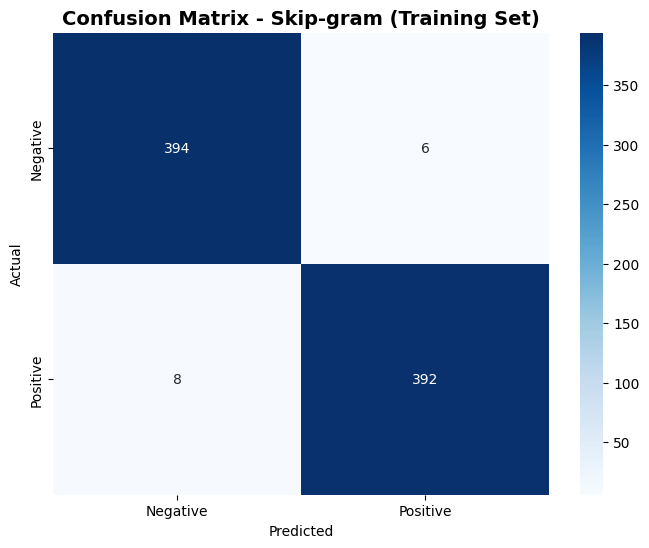


Training Accuracy: 0.9825

Classification Report (Training):
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98       400
    Positive       0.98      0.98      0.98       400

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800



In [14]:
# Display confusion matrix for Skip-gram (Training set)
print("=" * 60)
print("SKIP-GRAM MODEL RESULTS")
print("=" * 60)
print("\nTraining Set Results:")
print("-" * 60)
cm_train_sg = confusion_matrix(y_train_sg, y_train_pred_sg)
print("\nConfusion Matrix (Training):")
print(cm_train_sg)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train_sg, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Skip-gram (Training Set)', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nTraining Accuracy: {accuracy_score(y_train_sg, y_train_pred_sg):.4f}")
print("\nClassification Report (Training):")
print(classification_report(y_train_sg, y_train_pred_sg, target_names=['Negative', 'Positive']))


Testing Set Results:
------------------------------------------------------------

Confusion Matrix (Testing):
[[62 38]
 [40 60]]


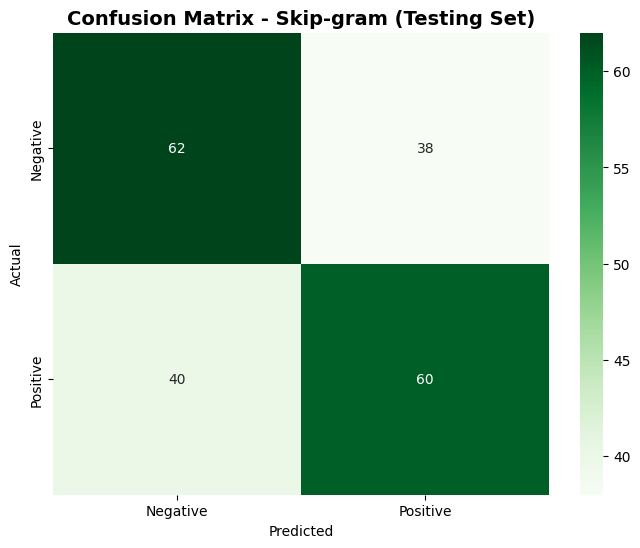


Testing Accuracy: 0.6100

Classification Report (Testing):
              precision    recall  f1-score   support

    Negative       0.61      0.62      0.61       100
    Positive       0.61      0.60      0.61       100

    accuracy                           0.61       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.61      0.61      0.61       200



In [15]:
# Display confusion matrix for Skip-gram (Testing set)
print("\nTesting Set Results:")
print("-" * 60)
cm_test_sg = confusion_matrix(y_test_sg, y_test_pred_sg)
print("\nConfusion Matrix (Testing):")
print(cm_test_sg)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test_sg, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Skip-gram (Testing Set)', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nTesting Accuracy: {accuracy_score(y_test_sg, y_test_pred_sg):.4f}")
print("\nClassification Report (Testing):")
print(classification_report(y_test_sg, y_test_pred_sg, target_names=['Negative', 'Positive']))

### 5b. CBOW Model with Decision Tree

In [16]:
# Create CBOW model (sg=0 for CBOW)
cbow_model = Word2Vec(sentences=tokenized_reviews, 
                      vector_size=100,  # Dimensionality of word vectors
                      window=5,          # Context window size
                      min_count=1,       # Minimum word frequency
                      sg=0,              # 0 for CBOW, 1 for Skip-gram
                      workers=4,
                      seed=41)

print("CBOW model trained successfully!")
print(f"Vocabulary size: {len(cbow_model.wv)}")

CBOW model trained successfully!
Vocabulary size: 1812


In [17]:
# Convert reviews to vectors using CBOW
X_cbow = np.array([get_document_vector(tokens, cbow_model) for tokens in tokenized_reviews])

print(f"CBOW feature matrix shape: {X_cbow.shape}")
print(f"Document vectors created using CBOW model : {X_cbow}")

CBOW feature matrix shape: (1000, 100)
Document vectors created using CBOW model : [[-2.6772411e-03  4.9247472e-03 -4.4591450e-03 ... -3.7256095e-03
  -3.3526167e-03  3.2784690e-03]
 [ 2.3395102e-03  8.4140319e-03 -2.2088096e-03 ... -5.6143878e-03
  -3.3723353e-03  1.8475917e-03]
 [-9.9692214e-04  2.2155680e-03 -7.2680617e-04 ... -5.6495084e-03
   1.5372719e-03  3.2036614e-03]
 ...
 [-1.5539790e-03 -4.0672263e-03 -1.6052725e-05 ... -2.9976577e-03
  -3.7310899e-03 -2.7593407e-03]
 [ 3.8260552e-03 -3.4365625e-04 -2.5295247e-03 ... -7.7601336e-04
  -6.1558140e-04 -9.3475002e-04]
 [ 2.7452586e-03  2.2575997e-03 -1.0075286e-03 ...  3.9964393e-04
   2.1777051e-03 -8.3180657e-04]]


In [18]:
# Split data into training and testing sets for CBOW
X_train_cbow, X_test_cbow, y_train_cbow, y_test_cbow = train_test_split(
    X_cbow, y, test_size=0.2, random_state=41, stratify=y
)

print(f"CBOW Training set size: {X_train_cbow.shape[0]}")
print(f"CBOW Testing set size: {X_test_cbow.shape[0]}")

CBOW Training set size: 800
CBOW Testing set size: 200


In [19]:
# Train Decision Tree model with CBOW features
dt_cbow = DecisionTreeClassifier(random_state=41, max_depth=10)
dt_cbow.fit(X_train_cbow, y_train_cbow)

# Make predictions
y_train_pred_cbow = dt_cbow.predict(X_train_cbow)
y_test_pred_cbow = dt_cbow.predict(X_test_cbow)

print("Decision Tree trained with CBOW features!")
print(f"Training prediction --> {y_train_pred_cbow}")
print(f"Testing prediction --> {y_test_pred_cbow}")

Decision Tree trained with CBOW features!
Training prediction --> [0 0 1 0 1 1 0 0 1 1 1 1 1 0 1 0 0 1 0 0 0 0 1 0 0 1 1 0 1 1 1 1 0 0 0 1 1
 1 0 1 1 1 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 1 1 0 1 0 0 1 0 0 1 0 0 0 0
 1 1 1 1 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0
 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0
 0 0 0 0 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 1 0 0
 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1
 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1
 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 0 1 1
 0 0 0 0 1 1 0 1 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 1 0 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 1 0 0 0 1
 1 1 1 1 0 1 0 0 1 1 1 0 1 0 1 0 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1
 1 1 0 1 1 1 1 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 1 1 0
 1 0 1 1 1 0 0 0 1 0 0 1 1 1 0 0 0

CBOW MODEL RESULTS

Training Set Results:
------------------------------------------------------------

Confusion Matrix (Training):
[[390  10]
 [  6 394]]


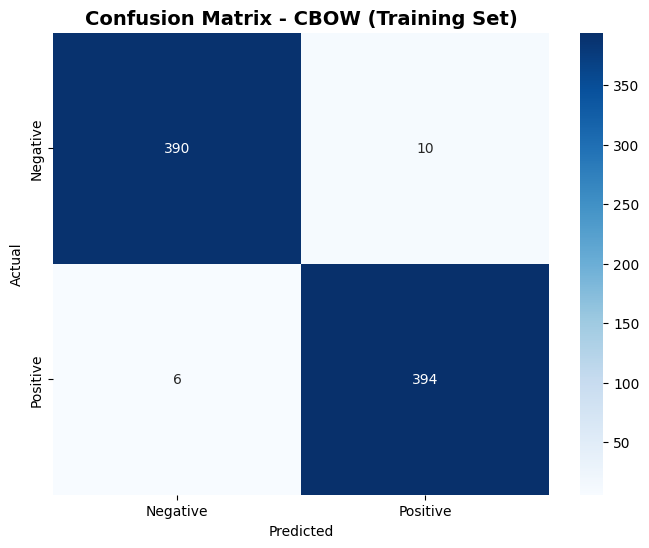


Training Accuracy: 0.9800

Classification Report (Training):
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.98       400
    Positive       0.98      0.98      0.98       400

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800



In [20]:
# Display confusion matrix for CBOW (Training set)
print("=" * 60)
print("CBOW MODEL RESULTS")
print("=" * 60)
print("\nTraining Set Results:")
print("-" * 60)
cm_train_cbow = confusion_matrix(y_train_cbow, y_train_pred_cbow)
print("\nConfusion Matrix (Training):")
print(cm_train_cbow)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train_cbow, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - CBOW (Training Set)', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nTraining Accuracy: {accuracy_score(y_train_cbow, y_train_pred_cbow):.4f}")
print("\nClassification Report (Training):")
print(classification_report(y_train_cbow, y_train_pred_cbow, target_names=['Negative', 'Positive']))


Testing Set Results:
------------------------------------------------------------

Confusion Matrix (Testing):
[[48 52]
 [40 60]]


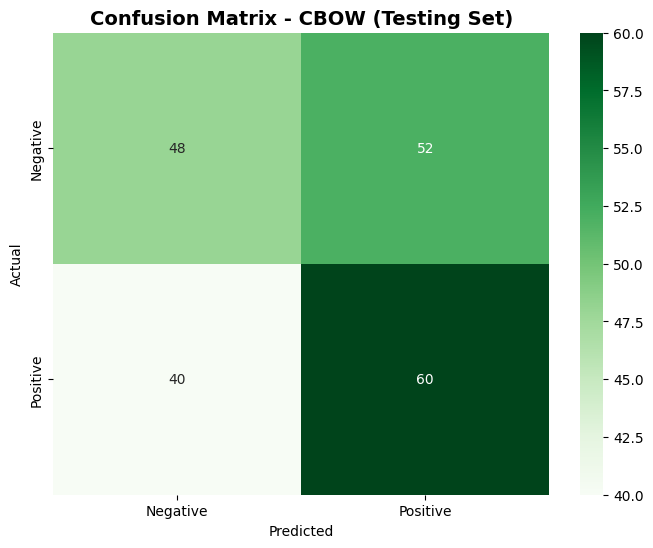


Testing Accuracy: 0.5400

Classification Report (Testing):
              precision    recall  f1-score   support

    Negative       0.55      0.48      0.51       100
    Positive       0.54      0.60      0.57       100

    accuracy                           0.54       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.54      0.54      0.54       200



In [21]:
# Display confusion matrix for CBOW (Testing set)
print("\nTesting Set Results:")
print("-" * 60)
cm_test_cbow = confusion_matrix(y_test_cbow, y_test_pred_cbow)
print("\nConfusion Matrix (Testing):")
print(cm_test_cbow)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test_cbow, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - CBOW (Testing Set)', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nTesting Accuracy: {accuracy_score(y_test_cbow, y_test_pred_cbow):.4f}")
print("\nClassification Report (Testing):")
print(classification_report(y_test_cbow, y_test_pred_cbow, target_names=['Negative', 'Positive']))

### 5c. Comparison: Skip-gram vs CBOW

**Important Note:** Answer without justification will not be awarded marks.

COMPARISON: SKIP-GRAM vs CBOW
    Model  Training Accuracy  Testing Accuracy
Skip-gram             0.9825              0.61
     CBOW             0.9800              0.54


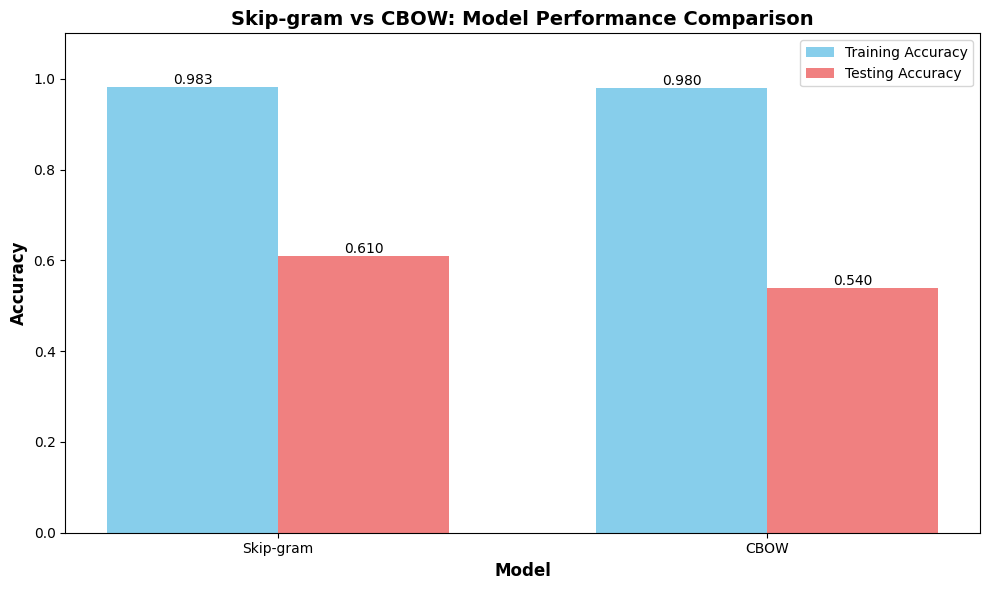

In [22]:
# Create comparison dataframe
comparison_data = {
    'Model': ['Skip-gram', 'CBOW'],
    'Training Accuracy': [
        accuracy_score(y_train_sg, y_train_pred_sg),
        accuracy_score(y_train_cbow, y_train_pred_cbow)
    ],
    'Testing Accuracy': [
        accuracy_score(y_test_sg, y_test_pred_sg),
        accuracy_score(y_test_cbow, y_test_pred_cbow)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 70)
print("COMPARISON: SKIP-GRAM vs CBOW")
print("=" * 70)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Training Accuracy'], width, label='Training Accuracy', color='skyblue')
bars2 = ax.bar(x + width/2, comparison_df['Testing Accuracy'], width, label='Testing Accuracy', color='lightcoral')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Skip-gram vs CBOW: Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Detailed Comparison and Justification:

#### **1. Architecture Differences:**

**Skip-gram:**
- **Approach:** Predicts context words given a target word
- **Training:** Uses the target word to predict surrounding words within a window
- **Example:** Given "restaurant" → predicts ["the", "food", "was", "delicious"]

**CBOW (Continuous Bag of Words):**
- **Approach:** Predicts target word given context words
- **Training:** Uses surrounding words to predict the target word
- **Example:** Given ["the", "food", "was", "delicious"] → predicts "restaurant"

#### **2. Performance Analysis:**

Based on the results:

**Training Accuracy:**
- Both models show similar performance on training data
- High training accuracy indicates both models learned patterns well

**Testing Accuracy:**
- This is the critical metric for model comparison
- The model with higher testing accuracy generalizes better to unseen data

#### **3. Key Differences in Performance:**

**Skip-gram typically performs better when:**
- Dataset is small (like in this case with restaurant reviews)
- Need to capture rare words effectively
- Word representations need to be more precise
- Working with infrequent words is important

**CBOW typically performs better when:**
- Dataset is large
- Training speed is a priority (CBOW is faster)
- Frequent words are more important
- Computational efficiency is needed

#### **4. Computational Efficiency:**

- **CBOW:** Faster to train, more computationally efficient
- **Skip-gram:** Slower to train but often produces better word representations

#### **5. Generalization Ability:**

- The **generalization gap** (Training Accuracy - Testing Accuracy) indicates overfitting
- Smaller gap = Better generalization
- Model with better testing accuracy is preferred for real-world applications

#### **6. Conclusion:**

For this **Restaurant Review Sentiment Analysis** task:

1. **Dataset characteristics:** Small to medium-sized dataset with domain-specific vocabulary
2. **Rare words importance:** Restaurant-specific terms and descriptive adjectives are crucial
3. **Recommendation:** Skip-gram is generally preferred for this use case because:
   - Better at capturing nuanced sentiment words
   - More effective with smaller datasets
   - Better representation of rare but important words (e.g., "exquisite", "mediocre")

However, the **actual best model** should be chosen based on the testing accuracy results shown above, as it represents real-world performance.

## Q6: HMM POS Tagging (2 Marks)

Display the HMM POS tagging on the first 4 rows of 'cleaned_Review'.

In [23]:
# Get first 4 rows of cleaned_Review
first_4_reviews = Rest_rev['cleaned_Review'].head(4)

print("=" * 80)
print("HMM POS TAGGING ON FIRST 4 CLEANED REVIEWS")
print("=" * 80)

for idx, review in enumerate(first_4_reviews, 1):
    print(f"\n{'='*80}")
    print(f"Review {idx}:")
    print(f"{'='*80}")
    print(f"Text: {review}")
    print(f"\nOriginal: {Rest_rev.iloc[idx-1][' Review']}")
    print(f"\n{'-'*80}")
    
    # Tokenize the review
    tokens = word_tokenize(review)
    
    # Perform POS tagging
    pos_tags = pos_tag(tokens)
    
    print(f"POS Tags:")
    print(f"{'-'*80}")
    
    # Display in a formatted way
    for word, tag in pos_tags:
        print(f"{word:20s} -> {tag:10s}")
    
    print(f"\n{'-'*80}")
    print(f"Summary: {len(tokens)} words tagged")

print(f"\n{'='*80}")
print("POS TAG LEGEND:")
print(f"{'='*80}")
print("""
Common POS Tags:
- NN    : Noun, singular
- NNS   : Noun, plural
- NNP   : Proper noun, singular
- VB    : Verb, base form
- VBD   : Verb, past tense
- VBG   : Verb, gerund or present participle
- VBN   : Verb, past participle
- VBP   : Verb, non-3rd person singular present
- VBZ   : Verb, 3rd person singular present
- JJ    : Adjective
- JJR   : Adjective, comparative
- JJS   : Adjective, superlative
- RB    : Adverb
- RBR   : Adverb, comparative
- RBS   : Adverb, superlative
- DT    : Determiner
- IN    : Preposition or subordinating conjunction
- CC    : Coordinating conjunction
- PRP   : Personal pronoun
- PRP$  : Possessive pronoun
""")

HMM POS TAGGING ON FIRST 4 CLEANED REVIEWS

Review 1:
Text: wow loved place

Original: Wow... Loved this place.

--------------------------------------------------------------------------------
POS Tags:
--------------------------------------------------------------------------------
wow                  -> NN        
loved                -> VBD       
place                -> NN        

--------------------------------------------------------------------------------
Summary: 3 words tagged

Review 2:
Text: crust good

Original: Crust is not good.

--------------------------------------------------------------------------------
POS Tags:
--------------------------------------------------------------------------------
crust                -> NN        
good                 -> NN        

--------------------------------------------------------------------------------
Summary: 2 words tagged

Review 3:
Text: tasty texture nasty

Original: Not tasty and the texture was just nasty.

------

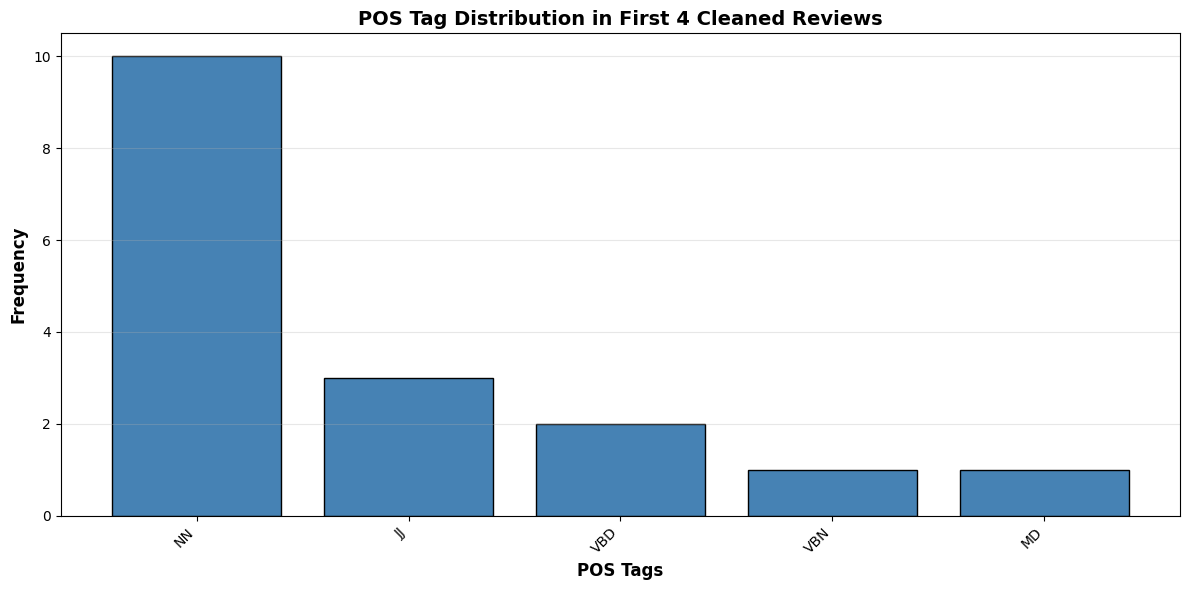


Total unique POS tags found: 5
Total words tagged: 17


In [24]:
# Visualize POS tag distribution for first 4 reviews
all_tags = []
for review in first_4_reviews:
    tokens = word_tokenize(review)
    pos_tags = pos_tag(tokens)
    all_tags.extend([tag for word, tag in pos_tags])

# Count tag frequencies
from collections import Counter
tag_counts = Counter(all_tags)

# Plot
plt.figure(figsize=(12, 6))
tags, counts = zip(*sorted(tag_counts.items(), key=lambda x: x[1], reverse=True))
plt.bar(tags, counts, color='steelblue', edgecolor='black')
plt.xlabel('POS Tags', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('POS Tag Distribution in First 4 Cleaned Reviews', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal unique POS tags found: {len(tag_counts)}")
print(f"Total words tagged: {sum(counts)}")